In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/NLP/Translation')

print("📂 Current dir:", os.getcwd())
print("\n📁 İçerik:")
!ls

📂 Current dir: /content/drive/MyDrive/NLP/Translation

📁 İçerik:
'arabic dataset'			    get-pip.py.1
'CELAL ŞAMİL KARTOĞLU MAKALE TASLAK.docx'  'italian dataset'
'chinese dataset'			    merged_datasets
 Datasets.ipynb				    sentiment_gpt3_train.jsonl
'Datasets v2.ipynb'			   'Translation v1.ipynb'
 final_models				   'Translation v2.ipynb'
'french dataset'			   'Translation v3.ipynb'
 get-pip.py


In [ ]:
data_dir = "/content/drive/MyDrive/NLP/Translation/merged_datasets"

print("📂 merged_datasets içeriği:\n")
print(os.listdir(data_dir))

📂 merged_datasets içeriği:

['arabic_merged_3class.csv', 'arabic_merged_3class_clean_final.csv', 'chinese_merged_3class_clean_final.csv', 'french_merged_3class_clean_final.csv', 'italian_merged_3class_clean_final.csv', 'merged_all_languages_clean.csv', 'merged_balanced.csv', 'merged_balanced_translated_libre_fixed.csv', 'arabic_merged.csv', 'arabic_merged_clean.csv', 'chinese_merged.csv', 'chinese_merged_3class.csv', 'french_merged_3class.csv', 'italian_merged_3class.csv', 'merged_balanced_translated_google_clean.csv', 'merged_balanced_translated_mbart_clean.csv']


In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/NLP/Translation/merged_datasets/merged_balanced.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Veri seti yüklendi:", df.shape)
print("\n📂 Sütunlar:")
print(df.columns.tolist())

print("\n🔍 İlk 3 satır:")
display(df.head(3))

print("\n🎯 Class dağılımı:")
print(df["sentiment"].value_counts())

✅ Veri seti yüklendi: (12000, 3)

📂 Sütunlar:
['text', 'sentiment', 'language']

🔍 İlk 3 satır:


,text,sentiment,language
0,بطلنا نحكم على الناس من شكلهم و لبسهم و تمن خر...,NEG,ar
1,vérifier la quantité à la livraison jai acheté...,NEG,fr
2,برومو حلقة بائع الليمون ثاني حلقات الأنيميشن م...,NEG,ar



🎯 Class dağılımı:
sentiment
NEG        4864
POS        3840
NEUTRAL    3296
Name: count, dtype: int64


In [ ]:
df = df[["text", "sentiment", "language"]].copy()

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
df["label"] = df["sentiment"].map(label_map).astype(int)

print("✅ Shape:", df.shape)

print("\n🎯 Label dağılımı:")
print(df["label"].value_counts())

print("\n🔍 Örnek veri:")
display(df.sample(5, random_state=42))

✅ Shape: (12000, 4)

🎯 Label dağılımı:
label
0    4864
2    3840
1    3296
Name: count, dtype: int64

🔍 Örnek veri:


,text,sentiment,language,label
1935,残破不堪的包装 快递的外包装盒残破不堪封条藕断丝连更过份的是内包装都被撕破还有一个不知道什么...,NEUTRAL,zh,1
6494,تم الاستماع إلى أقوالي اليوم في البلاغ المقدم ...,NEG,ar,0
1720,argentina lavitola tornerà in italia corriereit,NEUTRAL,it,1
9120,ho appena ricevuto la telefonata del president...,POS,it,2
360,البابا شنودة الثالث كان وطنيا مخلصا ومصريا عظي...,POS,ar,2


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def macro_specificity(y_true, y_pred, num_labels=3):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
    specs = []
    total = cm.sum()
    for i in range(num_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))

def compute_metrics_fn(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_w": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_w": recall_score(labels, preds, average="weighted", zero_division=0),
        "specificity_macro": macro_specificity(labels, preds),
    }

print("✅ Metrics hazır")

✅ Metrics hazır


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print("✅ mBERT tokenizer hazır")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ mBERT tokenizer hazır


In [ ]:
from sklearn.model_selection import StratifiedKFold
from datasets import Dataset

SEED = 42
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("✅ K-Fold hazır")

✅ K-Fold hazır


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

import numpy as np

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df["text"], df["label"]), 1):

    print(f"\n🚀 Fold {fold} başlıyor...")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
    val_dataset = Dataset.from_pandas(val_df[["text", "label"]])

    train_enc = train_dataset.map(tokenize_batch, batched=True)
    val_enc = val_dataset.map(tokenize_batch, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3
    )

    args = TrainingArguments(
        output_dir=f"/content/mbert_fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        logging_dir=f"/content/logs_mbert_{fold}",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_enc,
        eval_dataset=val_enc,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    )

    trainer.train()

    metrics = trainer.evaluate()
    print(f"📊 Fold {fold} sonuç:", metrics)

    fold_results.append(metrics)


avg_acc = np.mean([r["eval_accuracy"] for r in fold_results])
avg_f1 = np.mean([r["eval_f1_weighted"] for r in fold_results])

print("\n🔥 mBERT FINAL SONUÇ")
print(f"Accuracy: {avg_acc:.4f}")
print(f"F1 (weighted): {avg_f1:.4f}")


🚀 Fold 1 başlıyor...


Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

📊 Fold 5 sonuç: {'eval_loss': 0.8156042695045471, 'eval_accuracy': 0.6433333333333333, 'eval_f1_weighted': 0.6369300454882131, 'eval_f1_macro': 0.6226912288171037, 'eval_precision_w': 0.634589446559323, 'eval_recall_w': 0.6433333333333333, 'eval_specificity_macro': 0.8198251714478895, 'eval_runtime': 4.2505, 'eval_samples_per_second': 564.642, 'eval_steps_per_second': 17.645, 'epoch': 3.0}

🔥 mBERT FINAL SONUÇ
Accuracy: 0.6515
F1 (weighted): 0.6474


In [ ]:
import numpy as np

metrics_keys = [
    "eval_accuracy",
    "eval_precision_w",
    "eval_recall_w",
    "eval_f1_weighted",
    "eval_specificity_macro"
]

avg_metrics = {}

for key in metrics_keys:
    avg_metrics[key] = np.mean([fold[key] for fold in fold_results])

print("\n🔥 mBERT ORTALAMA SONUÇ (5-FOLD)")
print(f"Accuracy     : {avg_metrics['eval_accuracy']:.4f}")
print(f"Precision    : {avg_metrics['eval_precision_w']:.4f}")
print(f"Recall       : {avg_metrics['eval_recall_w']:.4f}")
print(f"F1-Score     : {avg_metrics['eval_f1_weighted']:.4f}")
print(f"Specificity  : {avg_metrics['eval_specificity_macro']:.4f}")


🔥 mBERT ORTALAMA SONUÇ (5-FOLD)
Accuracy     : 0.6515
Precision    : 0.6459
Recall       : 0.6515
F1-Score     : 0.6474
Specificity  : 0.8234


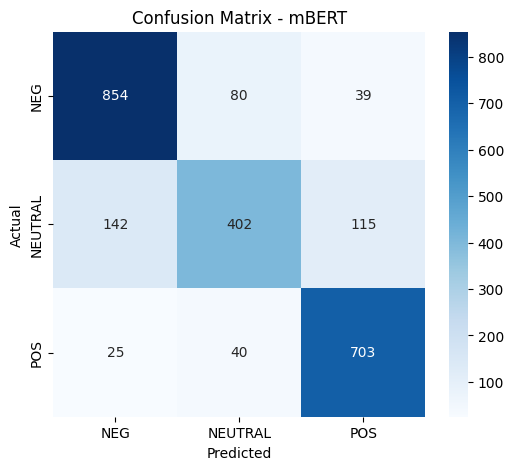

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(val_enc)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

labels = ["NEG", "NEUTRAL", "POS"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - mBERT")

plt.savefig("/content/drive/MyDrive/NLP/Translation/mbert_confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/NLP/Translation/mbert_final"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("✅ mBERT model kaydedildi:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ mBERT model kaydedildi: /content/drive/MyDrive/NLP/Translation/mbert_final


In [ ]:
from transformers import AutoTokenizer

xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

print("✅ XLM-R tokenizer hazır")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ XLM-R tokenizer hazır


In [ ]:
def tokenize_batch_xlmr(batch):
    return xlmr_tokenizer(batch["text"], truncation=True, padding=True, max_length=128)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )

    cm = confusion_matrix(labels, preds)
    specificity_per_class = []

    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_per_class.append(specificity)

    specificity_macro = np.mean(specificity_per_class)

    return {
        "accuracy": accuracy,
        "precision_w": precision,
        "recall_w": recall,
        "f1_weighted": f1,
        "specificity_macro": specificity_macro
    }

In [31]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

xlmr_fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df["text"], df["label"])):
    print(f"\n🚀 XLM-R Fold {fold+1} başlıyor...")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
    val_dataset = Dataset.from_pandas(val_df[["text", "label"]])

    train_enc = train_dataset.map(tokenize_batch_xlmr, batched=True)
    val_enc = val_dataset.map(tokenize_batch_xlmr, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base",
        num_labels=3
    )

    args = TrainingArguments(
        output_dir=f"/content/xlmr_fold_{fold+1}",

        learning_rate=1e-5,
        weight_decay=0.05,
        warmup_ratio=0.1,

        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,

        num_train_epochs=4,

        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,

        logging_dir="./logs",
        logging_steps=50,

        seed=42,
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_enc,
        eval_dataset=val_enc,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    metrics = trainer.evaluate()

    print(f"📊 Fold {fold+1} sonuç:", metrics)
    xlmr_fold_results.append(metrics)


🚀 XLM-R Fold 1 başlıyor...


Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecat

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

📊 Fold 5 sonuç: {'eval_loss': 0.7446538209915161, 'eval_accuracy': 0.6858333333333333, 'eval_precision_w': 0.6862437018429073, 'eval_recall_w': 0.6858333333333333, 'eval_f1_weighted': 0.6859648228356683, 'eval_specificity_macro': 0.8421918767507003, 'eval_runtime': 4.5774, 'eval_samples_per_second': 524.313, 'eval_steps_per_second': 32.77, 'epoch': 4.0}


In [32]:
import numpy as np

metrics_keys = [
    "eval_accuracy",
    "eval_precision_w",
    "eval_recall_w",
    "eval_f1_weighted",
    "eval_specificity_macro"
]

avg_xlmr = {k: np.mean([f[k] for f in xlmr_fold_results]) for k in metrics_keys}

print("\n🔥 XLM-R ORTALAMA SONUÇ")
for k, v in avg_xlmr.items():
    print(k, ":", round(v,4))


🔥 XLM-R ORTALAMA SONUÇ
eval_accuracy : 0.6878
eval_precision_w : 0.6808
eval_recall_w : 0.6878
eval_f1_weighted : 0.6827
eval_specificity_macro : 0.8422


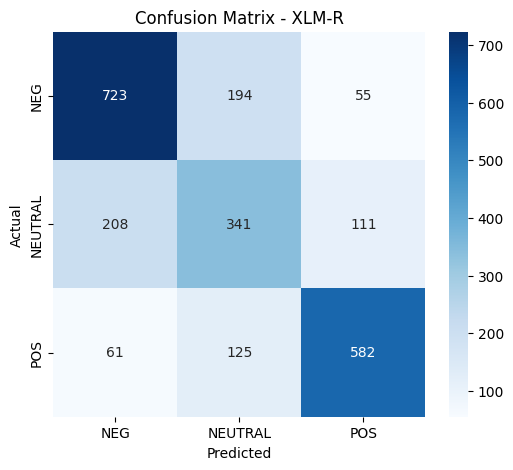

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(val_enc)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

labels = ["NEG", "NEUTRAL", "POS"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XLM-R")

plt.savefig(
    "/content/drive/MyDrive/NLP/Translation/xlmr_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [36]:
trainer.save_model("/content/drive/MyDrive/NLP/Translation/xlmr_best_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]